# Time Series Analysis: Basics and Theory



## Part 1: Introduction to Time Series

### What is Time Series Data?

A time series is a sequence of data points indexed in chronological order. Examples include:
- Daily stock prices
- Monthly sales figures
- Hourly temperature readings
- Annual GDP growth

### Key Characteristics:
- **Temporal ordering**: The sequence matters
- **Autocorrelation**: Observations are correlated with past values
- **Trend**: Long-term increase or decrease
- **Seasonality**: Regular patterns within fixed periods
- **Cyclicity**: Irregular long-term patterns

In [2]:
pip install statsmodels

     ---------------------------------------- 9.6/9.6 MB 6.1 MB/s eta 0:00:00
     -------------------------------------- 233.3/233.3 kB 4.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Create sample time series data for demonstration

dates = pd.date_range(start='2020-01-01', end='2023-12-31', freq='D')

# Create synthetic time series with trend, seasonality, and noise
np.random.seed(42)
#np.linspace(start, end, n)
trend = np.linspace(10, 20, len(dates))

seasonality = 5 * np.sin(2 * np.pi * np.arange(len(dates)) / 365.25)

#np.random.normal(mean, std, size)
noise = np.random.normal(0, 1, len(dates))

# Combine components
values = trend + seasonality + noise

# Create DataFrame
df = pd.DataFrame({
    'date': dates,
    'value': values
})
df.set_index('date', inplace=True)

print(f"Created time series with {len(df)} observations")
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head()

Created time series with 1461 observations
Date range: 2020-01-01 00:00:00 to 2023-12-31 00:00:00


,value
date,
2020-01-01,10.496714
2020-01-02,9.954593
2020-01-03,10.833377
2020-01-04,11.801500
2020-01-05,10.137021


In [ ]:
Value
 5 |    /\        /\        /\
   |   /  \      /  \      /  \
 0 |  /    \    /    \    /    \
   | /      \  /      \  /      \
-5 |/        \/        \/        \   
   ---------------------------------
   0        365       730      1095  Days
      Year 1     Year 2     Year 3

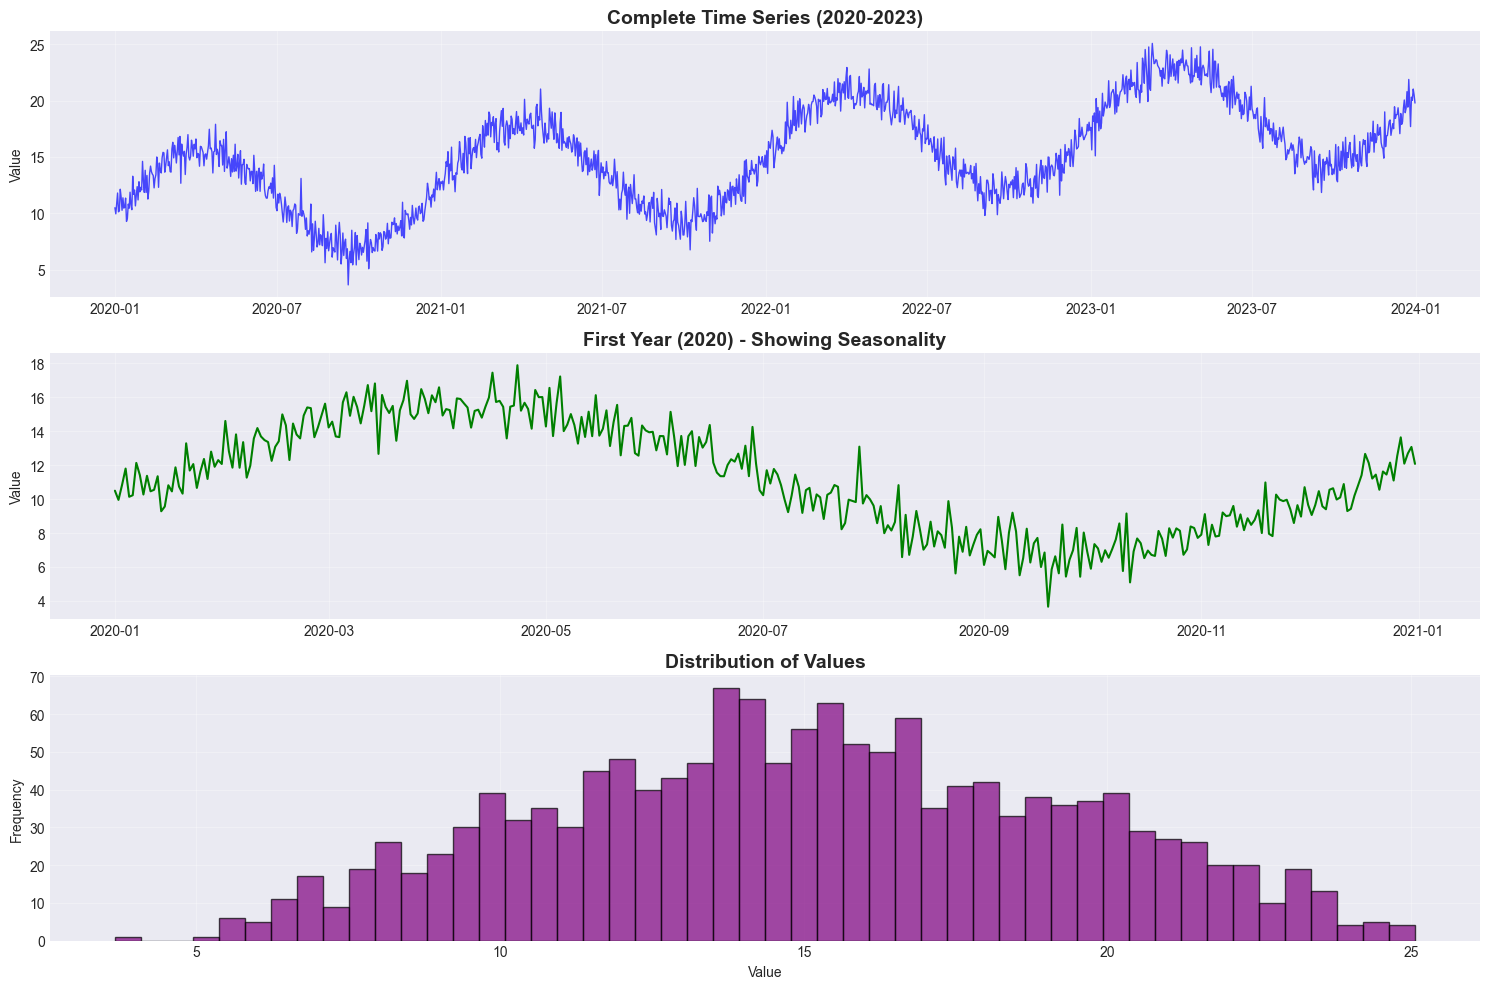

In [5]:
# Visualize the time series
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Plot 1: Full time series
axes[0].plot(df.index, df['value'], linewidth=1, color='blue', alpha=0.7)
axes[0].set_title('Complete Time Series (2020-2023)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Plot 2: First year only (to see seasonality)
first_year = df.loc['2020-01-01':'2020-12-31']
axes[1].plot(first_year.index, first_year['value'], linewidth=1.5, color='green')
axes[1].set_title('First Year (2020) - Showing Seasonality', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)

# Plot 3: Distribution
axes[2].hist(df['value'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[2].set_title('Distribution of Values', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: Components of Time Series

### The Four Main Components:

1. **Trend (T)**: Long-term direction (increasing, decreasing, or constant)
2. **Seasonal (S)**: Regular patterns that repeat over fixed periods
3. **Cyclical (C)**: Long-term oscillations without fixed period
4. **Irregular/Residual (I)**: Random noise after removing other components

### Decomposition Models:
- **Additive**: Y(t) = T(t) + S(t) + C(t) + I(t)
- **Multiplicative**: Y(t) = T(t) × S(t) × C(t) × I(t)

Choose additive when seasonal variations are constant over time,
multiplicative when they increase with trend.

In [6]:
# Perform time series decomposition
# First, ensure we have enough data (at least 2 full seasons)
decomposition = seasonal_decompose(df['value'], model='additive', period=365)

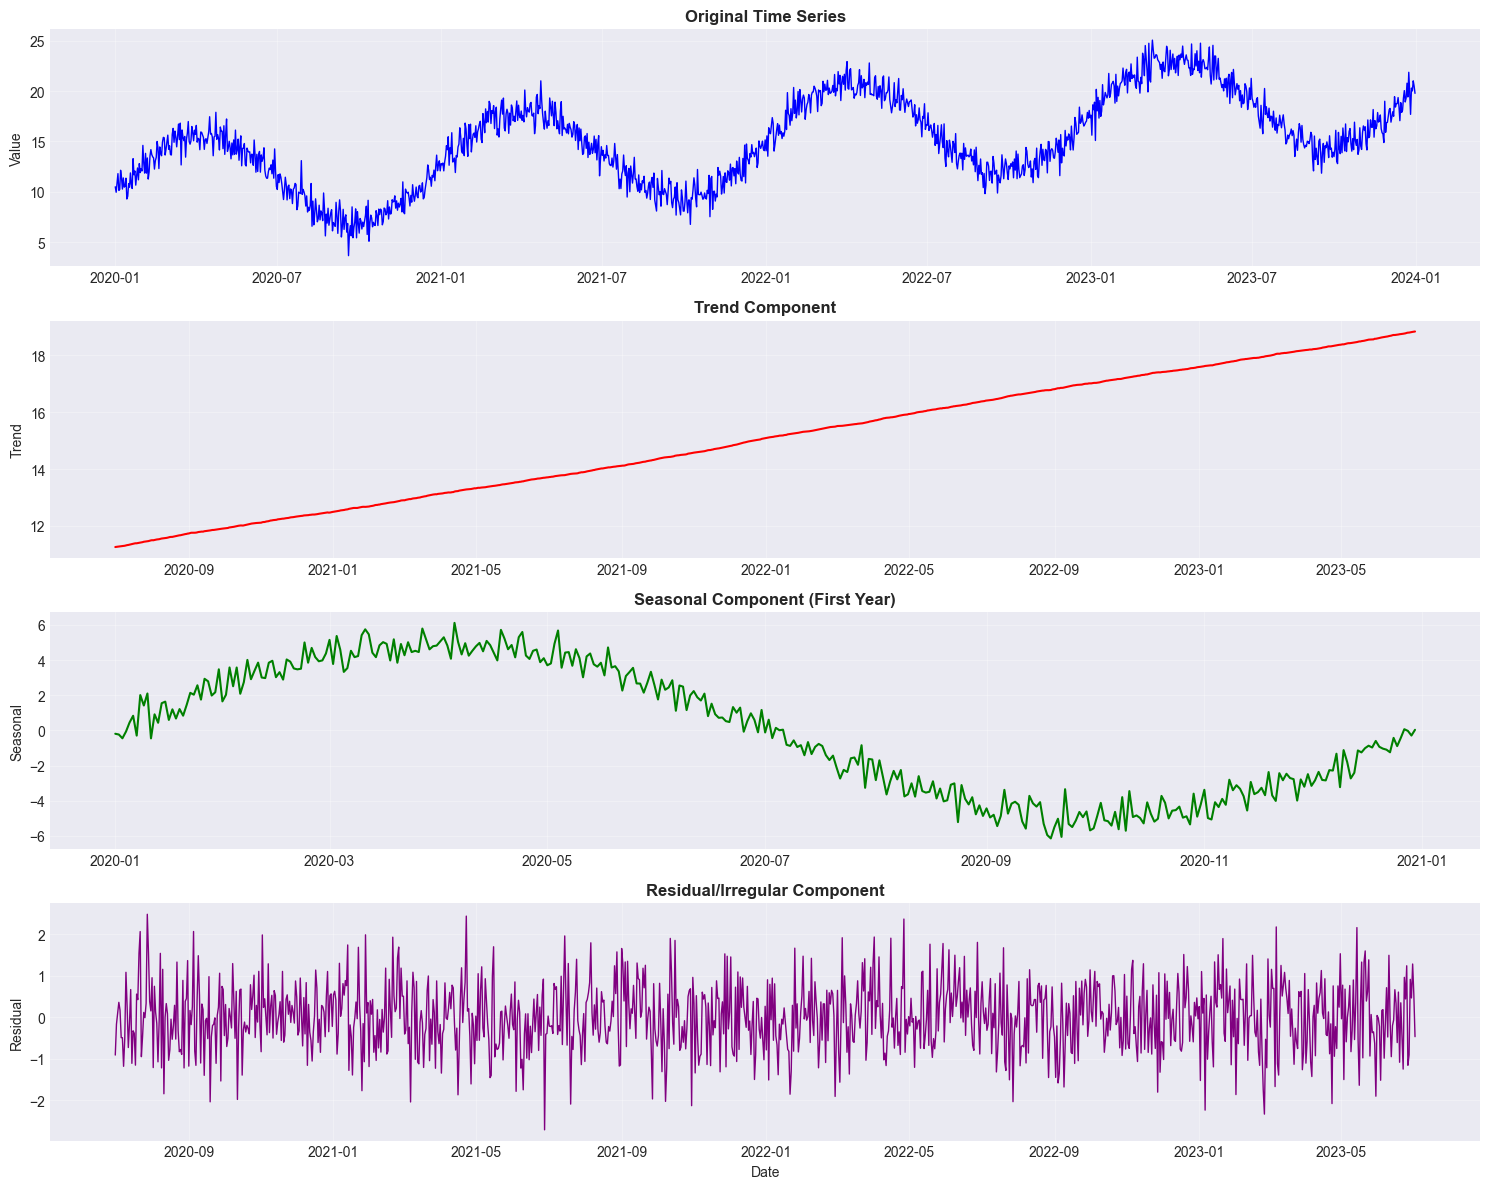


Component Statistics:
Trend range: 11.26 to 18.84
Seasonal range: -6.15 to 6.12
Residual range: -2.70 to 2.47


In [7]:
# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# Original
axes[0].plot(df.index, df['value'], linewidth=1, color='blue')
axes[0].set_title('Original Time Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Value')

# Trend
axes[1].plot(df.index, decomposition.trend, linewidth=1.5, color='red')
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend')

# Seasonal
axes[2].plot(df.index[:365], decomposition.seasonal[:365], linewidth=1.5, color='green')
axes[2].set_title('Seasonal Component (First Year)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal')

# Residual
axes[3].plot(df.index, decomposition.resid, linewidth=1, color='purple')
axes[3].set_title('Residual/Irregular Component', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nComponent Statistics:")
print(f"Trend range: {decomposition.trend.min():.2f} to {decomposition.trend.max():.2f}")
print(f"Seasonal range: {decomposition.seasonal.min():.2f} to {decomposition.seasonal.max():.2f}")
print(f"Residual range: {decomposition.resid.min():.2f} to {decomposition.resid.max():.2f}")

## Part 3: Stationarity 

### What is Stationarity?

A time series is stationary if its statistical properties (mean, variance, autocorrelation) are constant over time.

### Why Stationarity Matters:
- Most forecasting models assume stationarity
- Easier to model and predict
- Prevents spurious regression

### Types of Stationarity:
1. **Strict Stationarity**: Entire distribution is time-invariant
2. **Weak Stationarity**: Mean and variance constant, covariance depends only on lag

### How to Check Stationarity:
1. Visual inspection of plots
2. Summary statistics over different time windows
3. Statistical tests (Augmented Dickey-Fuller test)

Null hypothesis (H0): series is non-stationary

Alternative hypothesis (H1): series is stationary

p-value ≤ 0.05 → reject H0 → series is stationary

p-value > 0.05 → fail to reject H0 → series is non-stationary

STATIONARITY CHECK FOR ORIGINAL SERIES


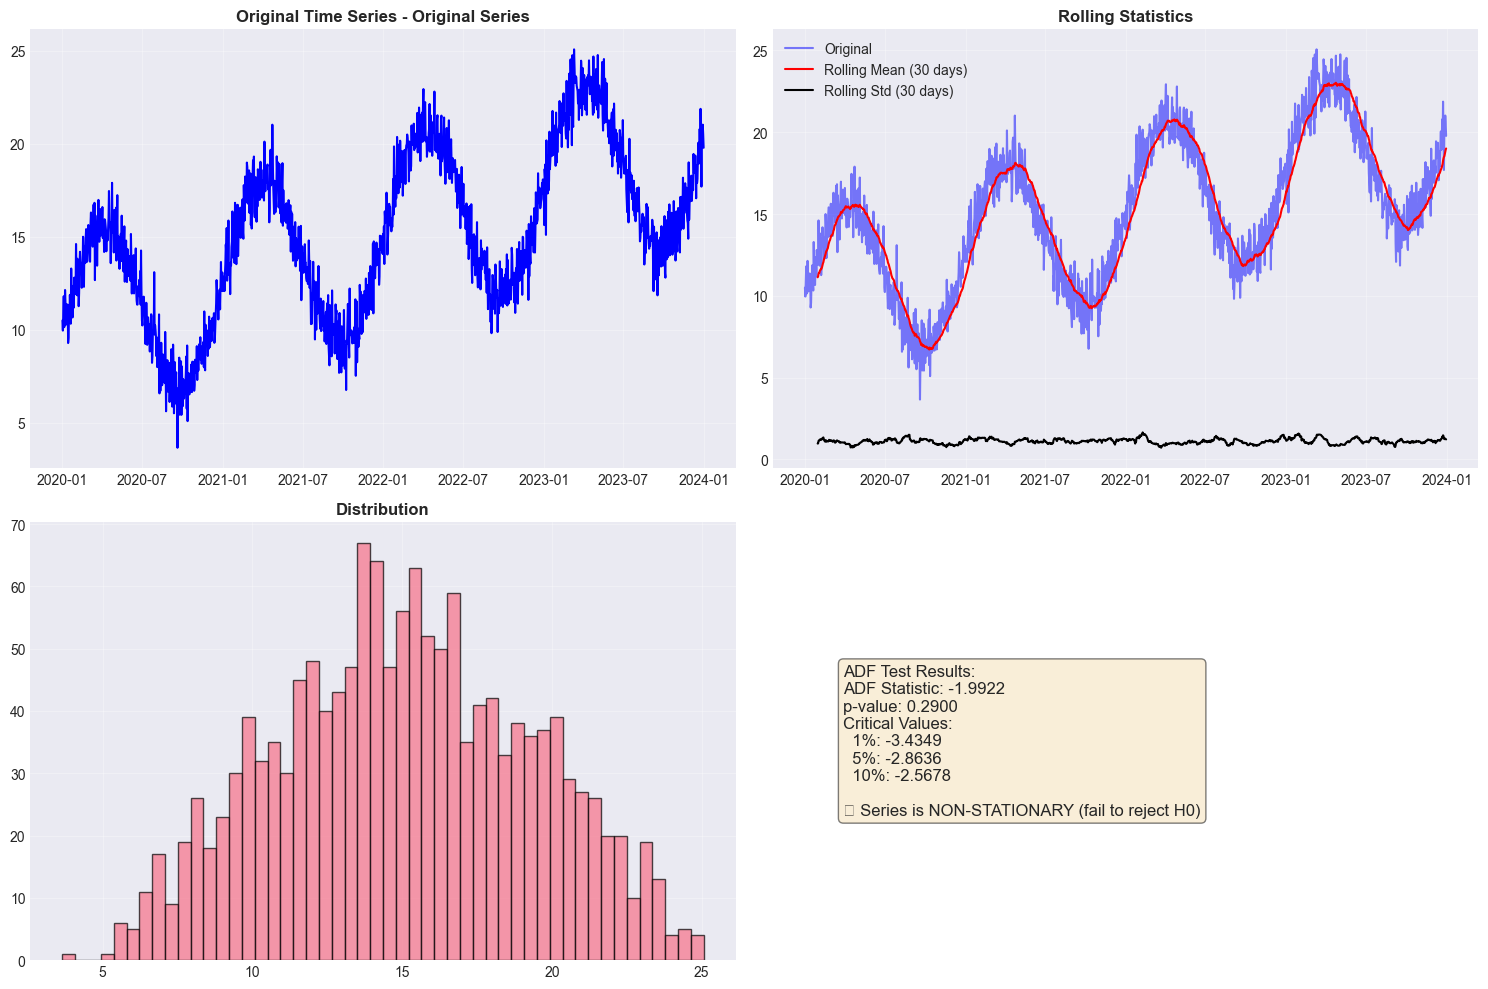

In [8]:
# Function to check stationarity
def check_stationarity(timeseries, title):
    """
    Check stationarity using visual methods and ADF test
    """
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Original series
    axes[0, 0].plot(timeseries, color='blue')
    axes[0, 0].set_title(f'{title} - Original Series', fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Rolling statistics
    rolling_mean = timeseries.rolling(window=30).mean()
    rolling_std = timeseries.rolling(window=30).std()
    
    axes[0, 1].plot(timeseries, color='blue', alpha=0.5, label='Original')
    axes[0, 1].plot(rolling_mean, color='red', label='Rolling Mean (30 days)')
    axes[0, 1].plot(rolling_std, color='black', label='Rolling Std (30 days)')
    axes[0, 1].set_title('Rolling Statistics', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Histogram
    axes[1, 0].hist(timeseries, bins=50, edgecolor='black', alpha=0.7)
    axes[1, 0].set_title('Distribution', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # ADF Test
    #Augmented Dickey-Fuller test
    adf_test = adfuller(timeseries.dropna(), autolag='AIC')
    
    adf_results = pd.Series(adf_test[0:4], 
                           index=['ADF Statistic', 'p-value', 
                                  'Lags Used', 'Observations'])
    
    # Display results in text box
    text = f"ADF Test Results:\n"
    text += f"ADF Statistic: {adf_test[0]:.4f}\n"
    text += f"p-value: {adf_test[1]:.4f}\n"
    text += f"Critical Values:\n"
    for key, value in adf_test[4].items():
        text += f"  {key}: {value:.4f}\n"
    
    if adf_test[1] <= 0.05:
        text += "\n✓ Series is STATIONARY (reject H0)"
    else:
        text += "\n✗ Series is NON-STATIONARY (fail to reject H0)"
    
    axes[1, 1].text(0.1, 0.5, text, transform=axes[1, 1].transAxes,
                   fontsize=12, verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return adf_test

# Check stationarity of our original series
print("="*60)
print("STATIONARITY CHECK FOR ORIGINAL SERIES")
print("="*60)
adf_results = check_stationarity(df['value'], 'Original Time Series')


STATIONARITY CHECK FOR DIFFERENCED SERIES


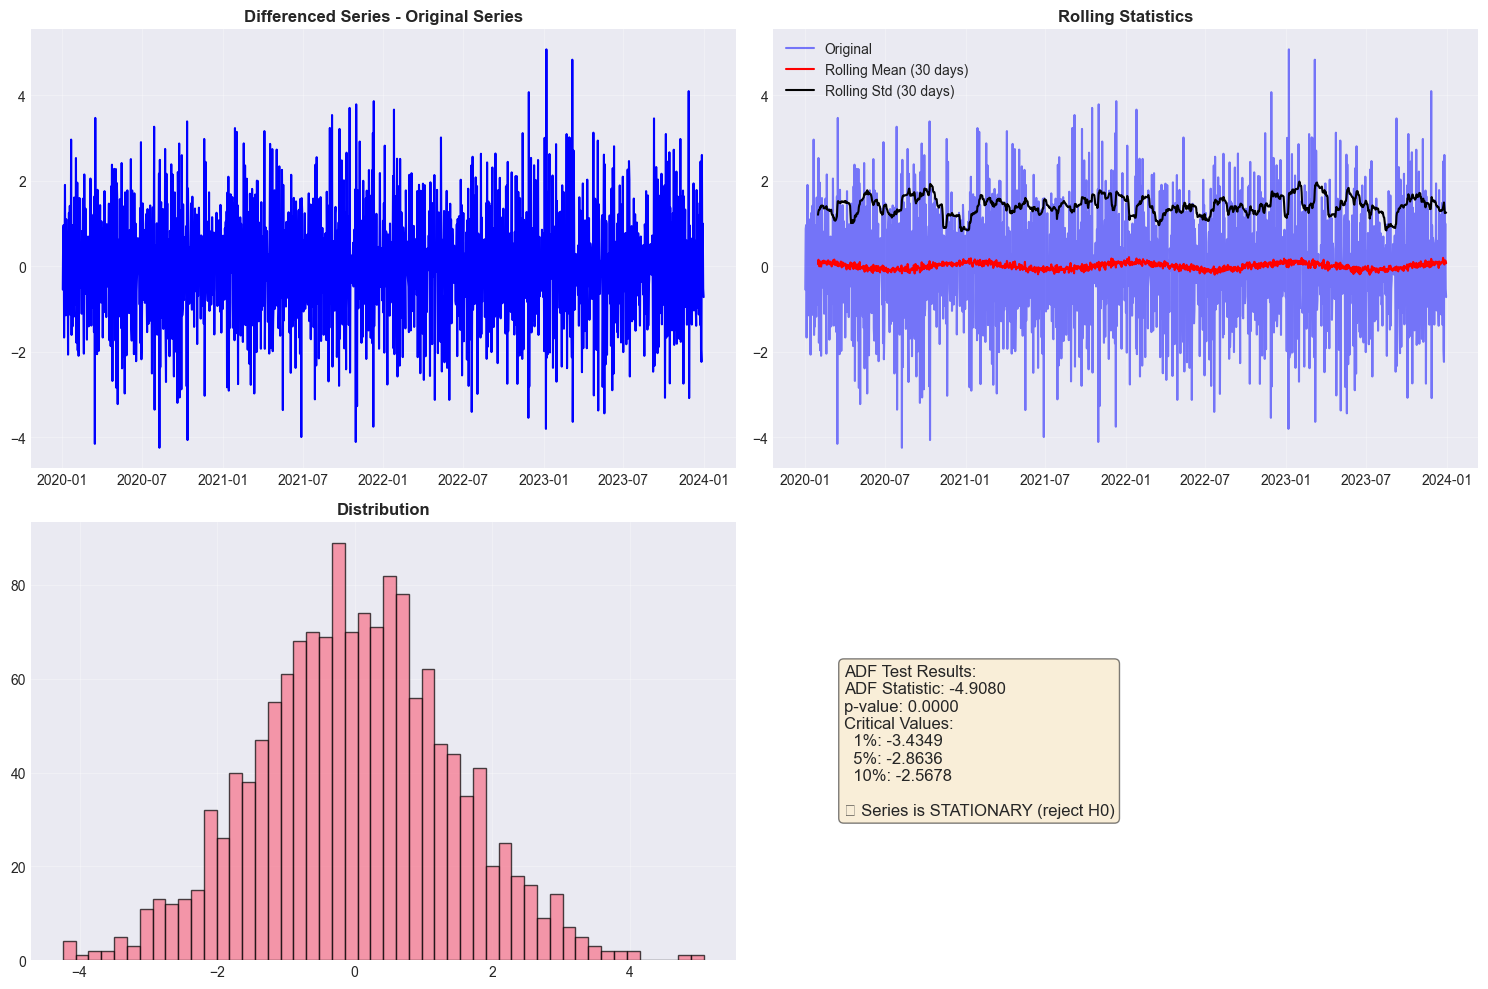

In [9]:
# Make the series stationary through differencing
df['value_diff'] = df['value'].diff()

# Check stationarity of differenced series
print("\n" + "="*60)
print("STATIONARITY CHECK FOR DIFFERENCED SERIES")
print("="*60)
adf_results_diff = check_stationarity(df['value_diff'].dropna(), 'Differenced Series')

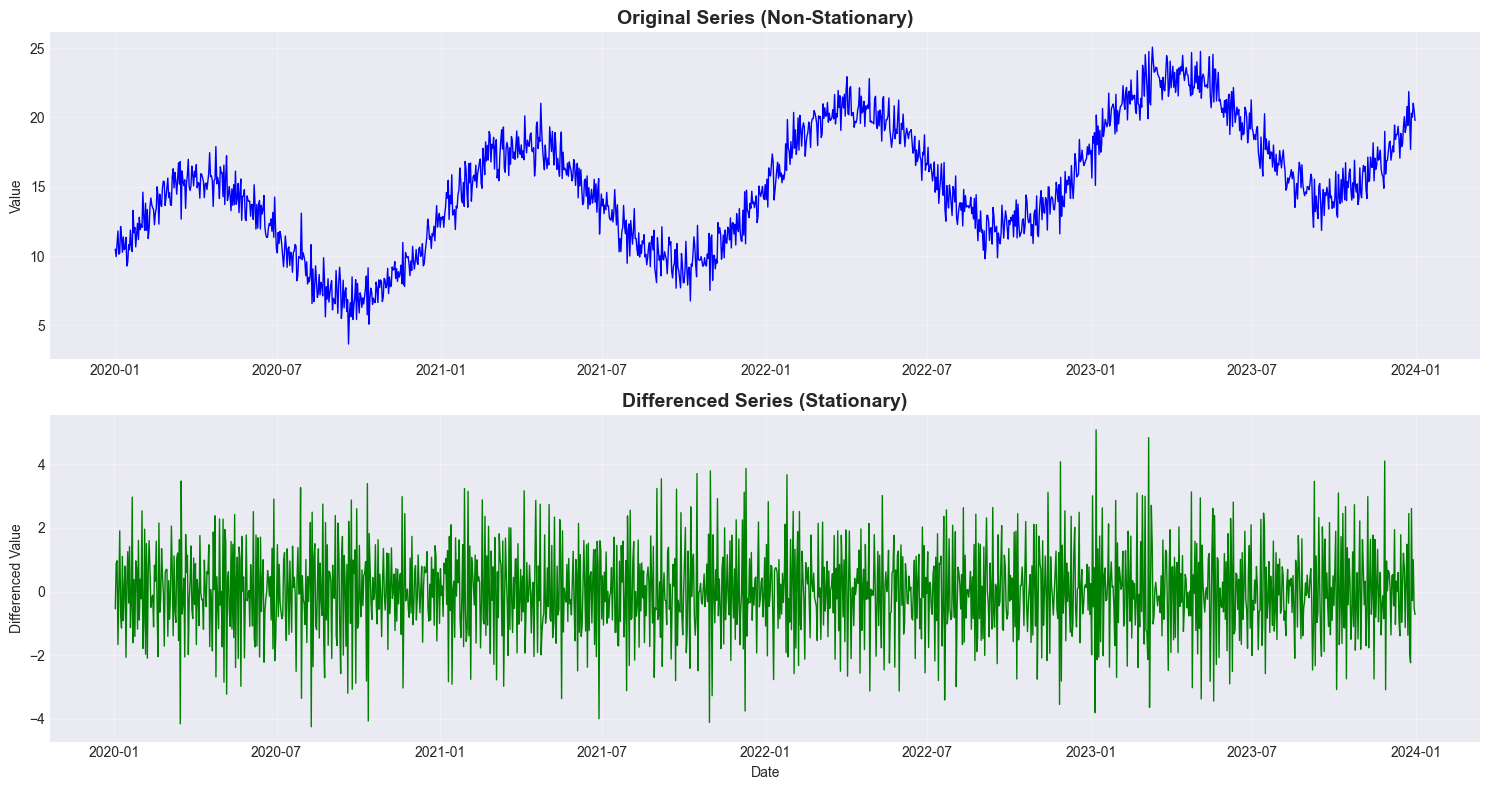

In [13]:
# Compare original vs differenced series
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Original
axes[0].plot(df.index, df['value'], linewidth=1, color='blue')
axes[0].set_title('Original Series (Non-Stationary)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Differenced
axes[1].plot(df.index, df['value_diff'], linewidth=1, color='green')
axes[1].set_title('Differenced Series (Stationary)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Differenced Value')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 4: Basic Forecasting Methods

### Simple Forecasting Techniques:

1. **Naive Method**: Forecast = last observed value
    - Best for random walk processes
    - Stock prices
    - Exchange rates
    - Any data where tomorrow is best predicted by today

2. **Seasonal Naive**: Forecast = last observed value from same season
   - Best for highly seasonal data
   - Monthly retail sales
    - Quarterly earnings
    - Daily website traffic
    - Weekly electricity consumption
    - Hourly temperature patterns

3. **Simple Average**: Forecast = mean of all historical values
   - Best for stable processes
   - Manufacturing defect rates
    - Stable quality metrics
    - Constant demand products
    - Random fluctuations around fixed mean

4. **Moving Average**: Forecast = mean of last k observations
   - Balances recent patterns with smoothness

5. **Exponential Smoothing**: Weighted average with exponentially decreasing weights
   - Gives more importance to recent observations

In [14]:
# Implement and compare basic forecasting methods
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Split data into train and test
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Define forecasting methods
def naive_forecast(train, test):
    """Naive method: use last observed value"""
    last_value = train['value'].iloc[-1]
    return pd.Series([last_value] * len(test), index=test.index)

def seasonal_naive_forecast(train, test, seasonal_period=7):
    """Seasonal naive: use last observed value from same season"""
    forecasts = []
    for i, date in enumerate(test.index):
        # Find the same day from previous season
        seasonal_idx = date - pd.Timedelta(days=seasonal_period)
        if seasonal_idx in train.index:
            forecasts.append(train.loc[seasonal_idx, 'value'])
        else:
            forecasts.append(train['value'].iloc[-1])
    return pd.Series(forecasts, index=test.index)

def moving_average_forecast(train, test, window=7):
    """Moving average forecast"""
    last_values = train['value'].iloc[-window:]
    return pd.Series([last_values.mean()] * len(test), index=test.index)

def simple_exponential_smoothing(train, test, alpha=0.3):
    """Simple exponential smoothing"""
    # Initialize with first value
    forecasts = []
    last_smooth = train['value'].iloc[0]
    
    # Smooth training data
    for value in train['value']:
        last_smooth = alpha * value + (1 - alpha) * last_smooth
    
    # Forecast test period
    for _ in range(len(test)):
        forecasts.append(last_smooth)
        # Update with forecast error if actual is known (for demonstration)
        # In real forecasting, you wouldn't have this step
    
    return pd.Series(forecasts, index=test.index)

# Generate forecasts
forecasts = {
    'Actual': test['value'],
    'Naive': naive_forecast(train, test),
    'Seasonal Naive (7d)': seasonal_naive_forecast(train, test, 7),
    'Moving Average (7d)': moving_average_forecast(train, test, 7),
    'Exponential Smoothing': simple_exponential_smoothing(train, test, 0.3)
}

In [15]:
# Calculate and display forecast accuracy
results = []
for name, forecast in forecasts.items():
    if name != 'Actual':
        mae = mean_absolute_error(forecasts['Actual'], forecast)
        rmse = np.sqrt(mean_squared_error(forecasts['Actual'], forecast))
        mape = np.mean(np.abs((forecasts['Actual'] - forecast) / forecasts['Actual'])) * 100
        
        results.append({
            'Method': name,
            'MAE': round(mae, 4),
            'RMSE': round(rmse, 4),
            'MAPE (%)': round(mape, 2)
        })

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('RMSE')

print("\n" + "="*60)
print("FORECAST METHOD COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))


FORECAST METHOD COMPARISON
               Method    MAE   RMSE  MAPE (%)
  Moving Average (7d) 4.9511 5.8550     30.91
                Naive 4.9632 5.8666     30.98
  Seasonal Naive (7d) 4.9932 5.8727     31.11
Exponential Smoothing 5.0674 5.9674     31.59


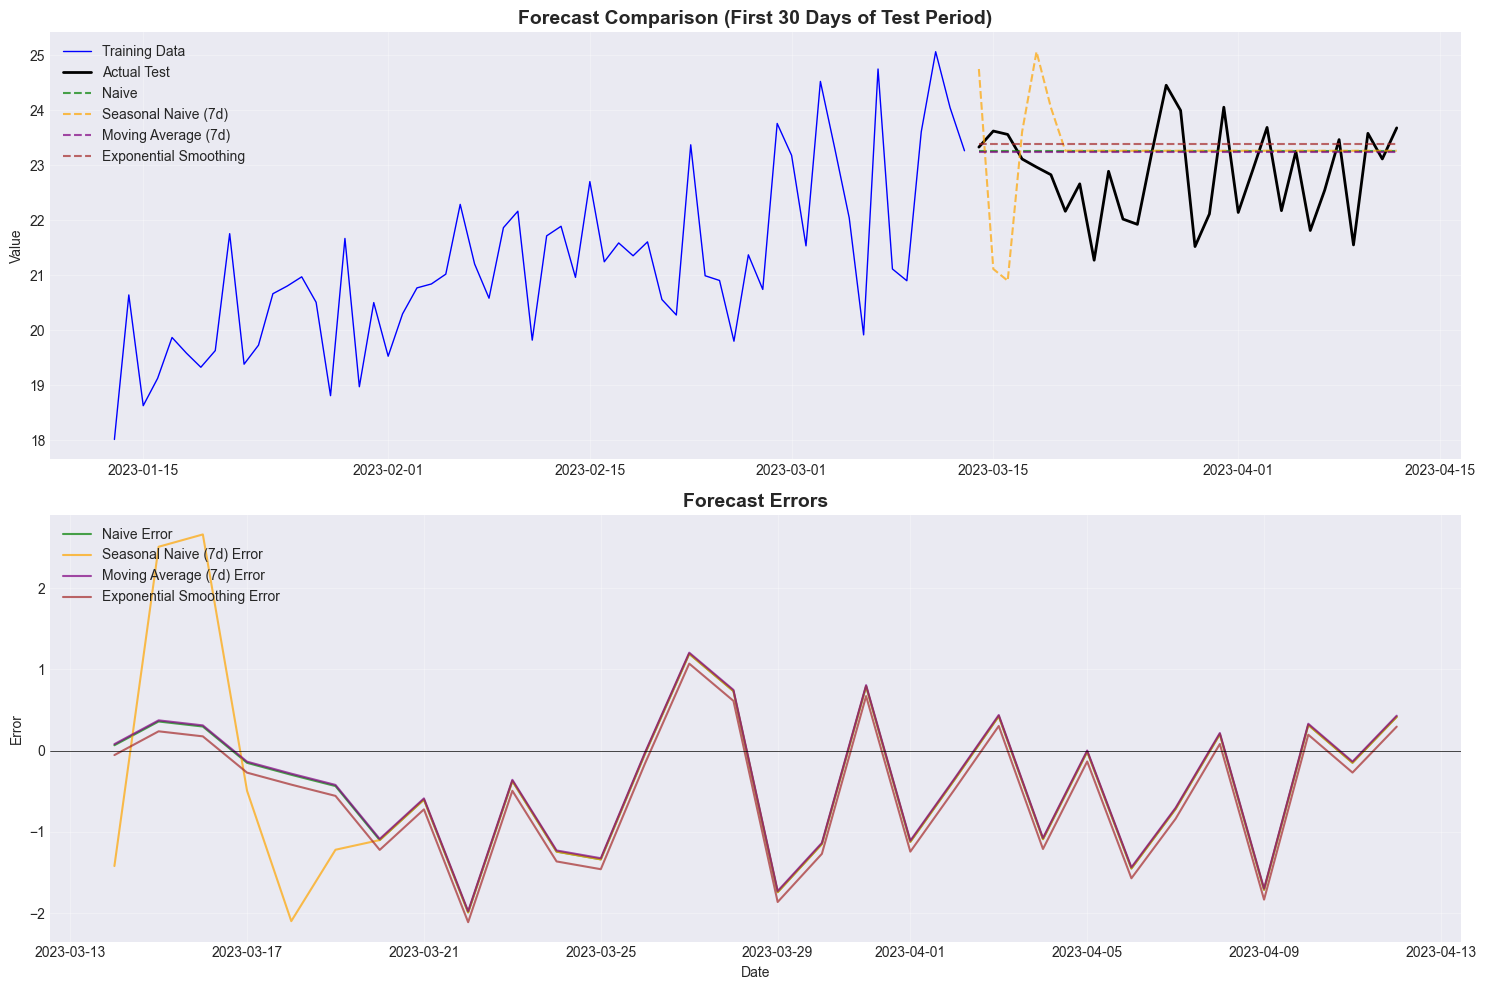

In [16]:
# Visualize forecasts
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: All forecasts
axes[0].plot(train.index[-60:], train['value'].iloc[-60:], 
            label='Training Data', color='blue', linewidth=1)
axes[0].plot(test.index[:30], test['value'].iloc[:30], 
            label='Actual Test', color='black', linewidth=2)

colors = ['red', 'green', 'orange', 'purple','brown']
for i, (name, forecast) in enumerate(forecasts.items()):
    if name != 'Actual':
        axes[0].plot(test.index[:30], forecast.iloc[:30], 
                    label=name, color=colors[i], linestyle='--', alpha=0.7)

axes[0].set_title('Forecast Comparison (First 30 Days of Test Period)', 
                 fontsize=14, fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: Forecast errors
for i, (name, forecast) in enumerate(forecasts.items()):
    if name != 'Actual':
        errors = forecasts['Actual'] - forecast
        axes[1].plot(test.index[:30], errors.iloc[:30], 
                    label=f'{name} Error', color=colors[i], alpha=0.7)

axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('Forecast Errors', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Error')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

def predict_future(df, forecast_method='moving_average', days_ahead=30, window=7, alpha=0.3):
    
    
    # Get the last date in your data
    last_date = df.index[-1]
    
    # Create future dates
    future_dates = pd.date_range(start=last_date + timedelta(days=1), 
                                 periods=days_ahead, freq='D')
    
    # Generate forecasts based on selected method
    if forecast_method == 'naive':
        # Naive method: last value repeated
        last_value = df['value'].iloc[-1]
        predictions = [last_value] * days_ahead
        
    elif forecast_method == 'moving_average':
        # Moving average: average of last 'window' values
        last_values = df['value'].iloc[-window:]
        ma_value = last_values.mean()
        predictions = [ma_value] * days_ahead
        
    elif forecast_method == 'seasonal_naive':
        # Seasonal naive: use same day from previous week
        predictions = []
        for i in range(days_ahead):
            seasonal_idx = last_date + timedelta(days=i+1) - timedelta(days=7)
            if seasonal_idx in df.index:
                predictions.append(df.loc[seasonal_idx, 'value'])
            else:
                predictions.append(df['value'].iloc[-1])
                
    elif forecast_method == 'exponential':
        # Exponential smoothing
        # Calculate final smoothed value
        smoothed = df['value'].iloc[0]
        for value in df['value']:
            smoothed = alpha * value + (1 - alpha) * smoothed
        predictions = [smoothed] * days_ahead
    
    # Create forecast DataFrame
    forecast_df = pd.DataFrame({
        'date': future_dates,
        'forecast': predictions
    })
    forecast_df.set_index('date', inplace=True)
    
    return forecast_df


future_forecast = predict_future(df, 
                                 forecast_method='moving_average', 
                                 days_ahead=30, 
                                 window=7)

print("\n📈 FUTURE PREDICTIONS (Next 30 Days)")
print("="*60)
print(f"Method: 7-day Moving Average")
print(f"Based on data up to: {df.index[-1].date()}")
print("\nPredictions:")
print(future_forecast.head(10).to_string())


📈 FUTURE PREDICTIONS (Next 30 Days)
Method: 7-day Moving Average
Based on data up to: 2023-12-31

Predictions:
             forecast
date                 
2024-01-01  19.887839
2024-01-02  19.887839
2024-01-03  19.887839
2024-01-04  19.887839
2024-01-05  19.887839
2024-01-06  19.887839
2024-01-07  19.887839
2024-01-08  19.887839
2024-01-09  19.887839
2024-01-10  19.887839


In [18]:
def recursive_forecast(df, days_ahead=30, window=7):
    """
    Recursive forecasting: updates the moving average as we predict each day
    This gives DIFFERENT values for each day
    """
    # Get historical values
    historical_values = df['value'].tolist()
    predictions = []
    
    # Get the last 'window' values from history
    last_window = historical_values[-window:]
    
    for day in range(days_ahead):
        # Calculate moving average from current window
        next_pred = np.mean(last_window)
        predictions.append(next_pred)
        
        # Update the window: remove oldest, add newest prediction
        last_window.pop(0)           # Remove oldest
        last_window.append(next_pred) # Add our new prediction
    
    return predictions

# Test it
recursive_preds = recursive_forecast(df, days_ahead=30, window=7)

print("\n🔄 RECURSIVE FORECAST (Different values each day)")
print("="*60)
for i, pred in enumerate(recursive_preds[:10], 1):
    print(f"Day {i}: {pred:.4f}")


🔄 RECURSIVE FORECAST (Different values each day)
Day 1: 19.8878
Day 2: 19.8827
Day 3: 20.1960
Day 4: 20.1816
Day 5: 20.2052
Day 6: 20.0890
Day 7: 20.0311
Day 8: 20.0676
Day 9: 20.0933
Day 10: 20.1234


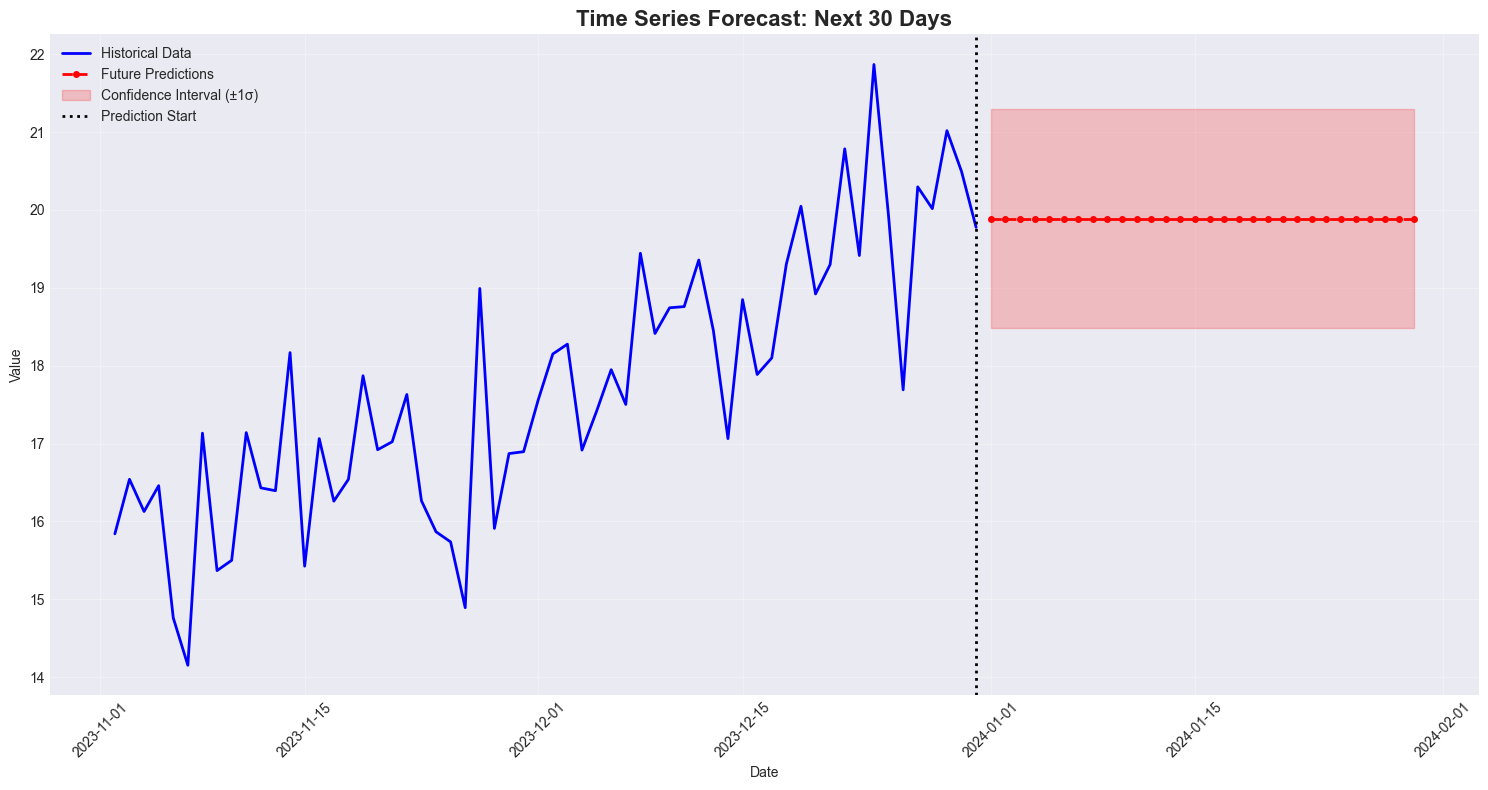

In [19]:
def plot_future_predictions(df, forecast_df, days_history=60):
    """
    Plot historical data along with future predictions
    """
    plt.figure(figsize=(15, 8))
    
    # Plot historical data
    plt.plot(df.index[-days_history:], df['value'].iloc[-days_history:], 
             'b-', label='Historical Data', linewidth=2)
    
    # Plot future predictions
    plt.plot(forecast_df.index, forecast_df['forecast'], 
             'r--', label='Future Predictions', linewidth=2, marker='o', markersize=4)
    
    # Add confidence interval (simple ±1 std dev of recent errors)
    recent_errors = df['value'].diff().std()  # Rough estimate
    plt.fill_between(forecast_df.index, 
                     forecast_df['forecast'] - recent_errors,
                     forecast_df['forecast'] + recent_errors,
                     color='red', alpha=0.2, label='Confidence Interval (±1σ)')
    
    # Add vertical line at prediction start
    plt.axvline(x=df.index[-1], color='black', linestyle=':', 
                label='Prediction Start', linewidth=2)
    
    plt.title('Time Series Forecast: Next 30 Days', fontsize=16, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot the predictions
plot_future_predictions(df, future_forecast, days_history=60)

## Practice Exercises

### Exercise 1: Identify Components
Look at the time series below and identify its components:
- Is there a trend?
- Is there seasonality?
- What period might the seasonality have?

### Exercise 2: Check Stationarity
Take any time series dataset (e.g., stock prices, weather data) and:
1. Plot the series
2. Calculate rolling statistics
3. Perform ADF test
4. Apply differencing if needed

### Exercise 3: Simple Forecasting
Using the last 30 days of our dataset:
1. Implement the naive method
2. Calculate forecast errors
3. Compare with moving average method

### Exercise 4: Decomposition
Decompose a time series of your choice:
1. Choose between additive and multiplicative
2. Interpret each component
3. Identify any unusual patterns in residuals

## References and Resources

### Books:
- "Forecasting: Principles and Practice" by Hyndman & Athanasopoulos
- "Time Series Analysis" by James D. Hamilton
- "Introductory Time Series with R" by Cowpertwait & Metcalfe

### Online Resources:
- [Forecasting: Principles and Practice (Free Online Textbook)](https://otexts.com/fpp3/)
- [Statsmodels Time Series Documentation](https://www.statsmodels.org/stable/tsa.html)
- [Kaggle Time Series Courses](https://www.kaggle.com/learn/time-series)

### Python Libraries to Explore:
- `statsmodels.tsa`: Comprehensive time series analysis
- `prophet`: Facebook's forecasting tool
- `sktime`: Unified framework for ML with time series
- `tsfresh`: Automatic feature extraction
- `darts`: Modern time series forecasting

### Practice Datasets:
- Air Passengers dataset
- Monthly sunspot numbers
- Daily minimum temperatures
- Stock market indices
- Energy consumption data

---

**Note:** This notebook provides a foundation for time series analysis. 
Practice regularly with real datasets to build intuition and expertise!